# 多特征逻辑回归 + 正则化（Regularized Logistic Regression）

用微芯片质量检测数据（`ex2data2.txt`）演示：

- **多特征**：原始只有 2 个特征，通过多项式映射扩展为 28 个特征
- **正则化**：用 $\lambda$ 惩罚项控制过拟合，对比 $\lambda = 0 / 1 / 100$ 的效果

## 数据集说明
- 第0列：microchip test 1（微芯片测试 1 得分）
- 第1列：microchip test 2（微芯片测试 2 得分）
- 第2列：accepted（芯片是否合格，1=合格，0=不合格）
- 该数据**线性不可分**，一条直线无法正确划分正负样本


In [23]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.lines as mlines
from itertools import combinations_with_replacement

# 配置 matplotlib 支持中文显示（避免 CJK 字形缺失警告）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False   # 修复负号显示为方块的问题

DATA_FILE = 'ex2data2.txt'

# 读取数据（Jupyter 中工作目录即 .ipynb 所在目录）
df_data = pd.read_csv(DATA_FILE, header=None)

print("===== 查看数据前五行 =====")
print(df_data.head())

print("===== 查看数据统计信息 =====")
print(df_data.describe())

# 取出正负样本
positive = df_data[df_data.iloc[:, -1] == 1]
negative = df_data[df_data.iloc[:, -1] == 0]


===== 查看数据前五行 =====
          0        1  2
0  0.051267  0.69956  1
1 -0.092742  0.68494  1
2 -0.213710  0.69225  1
3 -0.375000  0.50219  1
4 -0.513250  0.46564  1
===== 查看数据统计信息 =====
                0           1           2
count  118.000000  118.000000  118.000000
mean     0.054779    0.183102    0.491525
std      0.496654    0.519743    0.502060
min     -0.830070   -0.769740    0.000000
25%     -0.372120   -0.254385    0.000000
50%     -0.006336    0.213455    0.000000
75%      0.478970    0.646563    1.000000
max      1.070900    1.108900    1.000000


### 原始数据分布
肉眼可见正负样本交叉分布，无法用一条直线划分（线性不可分）。

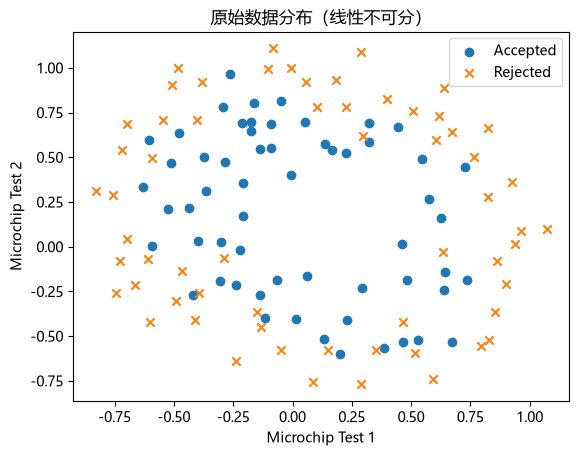

In [24]:
# 图 1：原始数据分布
plt.scatter(positive.iloc[:, 0], positive.iloc[:, 1], marker='o', label='Accepted')
plt.scatter(negative.iloc[:, 0], negative.iloc[:, 1], marker='x', label='Rejected')
plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.legend()
plt.title('原始数据分布（线性不可分）')
plt.show()


---

## 一、构造多特征：多项式特征映射

把 2 个原始特征 $x_1, x_2$ 映射为 $\text{degree}=3$ 次多项式：

$$1, x_1, x_2, x_1^2, x_1 x_2, x_2^2, \ldots, x_2^3$$

共 $\frac{(3+1)(3+2)}{2} = 10$ 个特征（第 1 列是偏置项全 1）。

> 特征多了之后模型表达能力强，但也更容易**过拟合**——这正是后面要用正则化的原因。

特征映射后按列标准化（只缩放特征列，偏置列保持全 1），帮助梯度下降更快收敛。


In [25]:
def map_feature(X, degree=3):
    # 把 n 个原始特征映射为 degree 次以内的所有多项式特征（第 1 列是偏置项全 1）
    # 通用支持任意数量特征：n 个特征、degree 次，特征总数 = C(degree+n, n)
    # 2 个特征、degree=3 时 = C(5,2) = 10 个
    m = X.shape[0]
    out = [np.ones(m)]   # 偏置列（全 1）
    for d in range(1, degree + 1):
        # 总次数为 d 的单项式：从 n 个特征中"有放回"取 d 个相乘，覆盖所有指数组合
        # 例如 n=2, d=2 时依次为 x0²、x0·x1、x1²
        for exps in combinations_with_replacement(range(X.shape[1]), d):
            feat = np.ones(m)
            for j in exps:
                feat *= X[:, j]
            out.append(feat)
    return np.column_stack(out)


# 提取原始特征与目标
X_raw = df_data.iloc[:, :-1].values
y = df_data.iloc[:, -1].values

# 多项式映射（含偏置列）
X_poly = map_feature(X_raw, degree=3)
print('多项式特征维度:', X_poly.shape)   # (118, 10)

# 特征缩放：只缩放特征列（第 1 列起），偏置列保持全 1
mu = np.mean(X_poly[:, 1:], axis=0)
sigma = np.std(X_poly[:, 1:], axis=0)
X = np.column_stack((np.ones(len(X_poly)), (X_poly[:, 1:] - mu) / sigma))


多项式特征维度: (118, 10)


### 特征设计：如何取值、如何判断

特征（这里主要指多项式映射的 degree）**不是随便定的**，靠"实验 + 评估"来选。核心做法：

#### 1. degree 如何取值（超参数选择）
- 从低到高尝试：degree = 1 → 3 → 6 → 10，观察效果
- 原则：**表达力够用即可**——degree 越低模型越简单、越不容易过拟合；degree 越高边界越复杂、越容易过拟合
- degree 与 $\lambda$ 配合使用：特征越多（degree 大），越需要用大 $\lambda$ 压住 $\theta$

#### 2. 如何判断特征好不好（评估方法）
正式做法是把数据拆成三份：
- **训练集**：用来学 $\theta$
- **验证集**：用来选 degree、$\lambda$ 等超参数
- **测试集**：只做最终评估，验证泛化能力

判断信号（训练集 vs 验证集准确率）：

| 现象 | 结论 | 对策 |
|---|---|---|
| 训练高、验证低 | 过拟合 | 降低 degree 或增大 $\lambda$ |
| 两者都低 | 欠拟合 | 提高 degree 或减小 $\lambda$ |
| 两者接近且都高 | 合适 | 保持 |

辅助手段：
- **决策边界可视化**（见上文图）：边界弯曲缠绕样本 = 过拟合；平滑 = 适中；接近直线 = 欠拟合
- **收敛曲线**：确认代价确实在下降

#### 3. 对应到本实验
本实验固定 degree=3，通过对比 $\lambda = 0 / 1 / 100$ 展示了"表达力过剩时如何用正则化管控"：
- $\lambda = 0$：边界高度弯曲（过拟合信号）
- $\lambda = 1$：平滑适中
- $\lambda = 100$：接近直线（欠拟合信号）

> 注：本示例只在训练集上算了准确率；实际工程中必须留出验证集/测试集做超参数选择与最终评估，否则无法判断真实泛化能力。



---

## 二、正则化逻辑回归

带正则化的代价函数：

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y_i \log h(x_i) - (1-y_i) \log(1 - h(x_i)) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$

- 第一项与普通逻辑回归相同，$h(x) = \text{sigmoid}(X\theta)$
- 第二项是**正则项**：对所有特征 $\theta_j\,(j \ge 1)$ 施加平方惩罚，$\theta_0$（偏置）不参与
- $\lambda$ 控制惩罚强度：$\lambda$ 越大，$\theta$ 被压得越小，模型越简单

梯度更新（$j \ge 1$ 比普通梯度多一项 $\frac{\lambda}{m}\theta_j$，等价于权重衰减）：

$$\theta_j = \theta_j - \alpha \left[ \frac{1}{m} X_j^T (h-y) + \frac{\lambda}{m} \theta_j \right], \qquad \theta_0 = \theta_0 - \alpha \cdot \frac{1}{m} X_0^T (h-y)$$


In [26]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def cost_function_reg(X, y, theta, lam):
    m = len(y)
    # 计算预测值（np.clip 防止 sigmoid 出现 0/1 导致 log(0)=inf/NaN）
    predictions = np.clip(sigmoid(X.dot(theta)), 1e-10, 1 - 1e-10)
    # 基础代价（与普通逻辑回归相同）
    cost = (1 / m) * np.sum(-y * np.log(predictions) - (1 - y) * np.log(1 - predictions))
    # 正则项：θ₀（theta[0]）不参与惩罚
    reg = (lam / (2 * m)) * np.sum(theta[1:] ** 2)
    return cost + reg


def gradient_descent_reg(X, y, theta, alpha, lam):
    m = len(y)
    predictions = sigmoid(X.dot(theta))
    # 普通梯度：(1/m)·Xᵀ(h-y)
    d_theta = (1 / m) * X.T.dot(predictions - y)
    # 正则化梯度：(λ/m)·θ，θ₀ 置零表示偏置不参与惩罚
    reg_grad = (lam / m) * theta
    reg_grad[0] = 0
    # 更新参数
    theta = theta - alpha * (d_theta + reg_grad)
    return theta


def batch_gradient_descent_reg(X, y, theta, alpha=0.1, epoch=5000, lam=0):
    cost_data = [cost_function_reg(X, y, theta, lam)]   # 初始代价（列表，方便 .append()）
    _theta = np.copy(theta)
    for i in range(epoch):
        _theta = gradient_descent_reg(X, y, _theta, alpha, lam)
        cost_data.append(cost_function_reg(X, y, _theta, lam))
    return _theta, cost_data


---

## 三、训练与 λ 对比

用相同初始化（θ=0）、学习率与迭代次数，训练三个模型：

- $\lambda = 0$：不惩罚 → 容易过拟合
- $\lambda = 1$：适中
- $\lambda = 100$：惩罚过强 → 欠拟合


In [27]:
alpha = 0.1     # 学习率
epoch = 5000    # 迭代次数
lambdas = [0, 1, 100]

models = {}
for lam in lambdas:
    theta_l, cost_l = batch_gradient_descent_reg(X, y, np.zeros(X.shape[1]), alpha, epoch, lam)
    models[lam] = (theta_l, cost_l)
    # 训练集准确率
    pred = (sigmoid(X.dot(theta_l)) >= 0.5).astype(int)
    acc = np.mean(pred == y)
    print(f'λ={lam:>3}: 最终代价 = {cost_l[-1]:.4f}, 训练集准确率 = {acc:.1%}')


λ=  0: 最终代价 = 0.3448, 训练集准确率 = 84.7%
λ=  1: 最终代价 = 0.4190, 训练集准确率 = 82.2%
λ=100: 最终代价 = 0.6617, 训练集准确率 = 72.0%


---

## 四、决策边界可视化

决策边界是非线性的（等高线）。做法：在原始特征空间生成网格 → 多项式映射 → 缩放 → 预测概率，然后画 **概率 = 0.5 的等高线**。

可以看到：$\lambda=0$ 边界弯曲缠绕（过拟合），$\lambda=1$ 平滑适中，$\lambda=100$ 几乎退化成直线（欠拟合）。


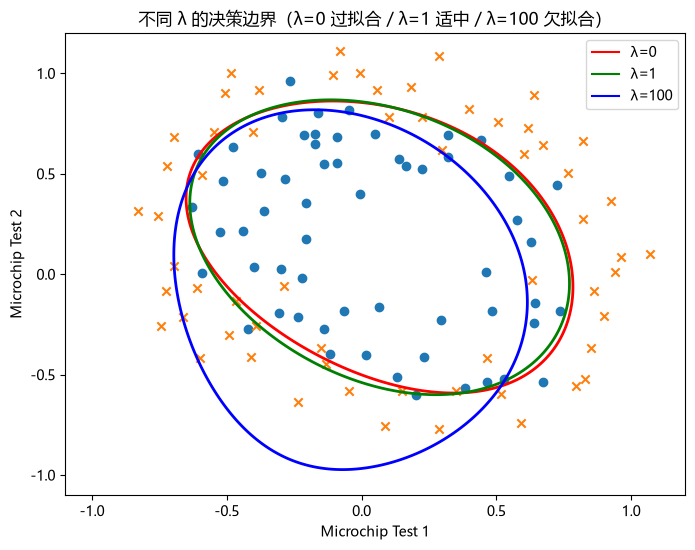

In [28]:
# 图 2：三个 λ 的决策边界（等高线）
plt.figure(figsize=(8, 6))
plt.scatter(positive.iloc[:, 0], positive.iloc[:, 1], marker='o', label='Accepted')
plt.scatter(negative.iloc[:, 0], negative.iloc[:, 1], marker='x', label='Rejected')

grid_x1, grid_x2 = np.meshgrid(np.linspace(-1.1, 1.2, 300), np.linspace(-1.1, 1.2, 300))
grid_pts = np.column_stack((grid_x1.ravel(), grid_x2.ravel()))
grid_poly = map_feature(grid_pts)
grid_X = np.column_stack((np.ones(len(grid_poly)), (grid_poly[:, 1:] - mu) / sigma))

colors = {0: 'red', 1: 'green', 100: 'blue'}
for lam in lambdas:
    theta_l = models[lam][0]
    prob = sigmoid(grid_X.dot(theta_l)).reshape(grid_x1.shape)
    # 概率 = 0.5 的等高线即决策边界
    plt.contour(grid_x1, grid_x2, prob, levels=[0.5], linewidths=2, colors=colors[lam])

plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.title('不同 λ 的决策边界（λ=0 过拟合 / λ=1 适中 / λ=100 欠拟合）')
handles = [
    mlines.Line2D([], [], color='red', label='λ=0'),
    mlines.Line2D([], [], color='green', label='λ=1'),
    mlines.Line2D([], [], color='blue', label='λ=100'),
]
plt.legend(handles=handles)
plt.show()


### 收敛曲线
三个模型都能收敛，$\lambda$ 越大最终代价越高（正则项贡献）。

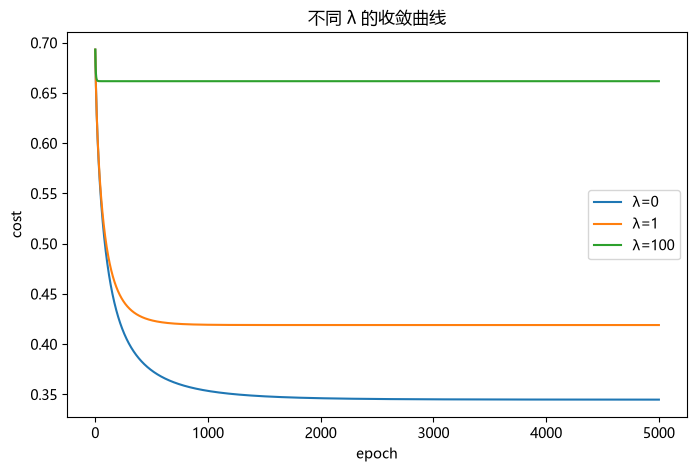

In [29]:
# 图 3：收敛曲线
plt.figure(figsize=(8, 5))
for lam in lambdas:
    plt.plot(models[lam][1], label=f'λ={lam}')
plt.xlabel('epoch')
plt.ylabel('cost')
plt.legend()
plt.title('不同 λ 的收敛曲线')
plt.show()


### 预测
新样本需走完整的 多项式映射 → 缩放 → sigmoid 流程（用 $\lambda=1$ 模型）。

In [30]:
# （可选）预测
new_x = np.array([0.2, -0.3])   # 例：test1=0.2，test2=-0.3
new_poly = map_feature(new_x.reshape(1, -1))
new_X = np.concatenate(([1], (new_poly[0, 1:] - mu) / sigma))
pred = sigmoid(new_X.dot(models[1][0]))
print(f'新样本 {new_x}: λ=1 模型预测合格概率 = {pred:.4f}')


新样本 [ 0.2 -0.3]: λ=1 模型预测合格概率 = 0.8950
